# HW4: Social Stocks

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [24]:
!ls /content/drive/Othercomputers/Mac/Desktop/DS训练营/hw4/hw4.ipynb

/content/drive/Othercomputers/Mac/Desktop/DS训练营/hw4/hw4.ipynb


In [114]:
import os
# GOOGLE_DRIVE_PATH_AFTER_MYDRIVE = 'hw4'
# GOOGLE_DRIVE_PATH = os.path.join('drive', 'My Drive', 'DS101', GOOGLE_DRIVE_PATH_AFTER_MYDRIVE)
GOOGLE_DRIVE_PATH = '/content/drive/Othercomputers/Mac/Desktop/DS训练营/hw4'
print(os.listdir(GOOGLE_DRIVE_PATH))

['hw4.ipynb', 'nvda.db', 'openai_visits.csv', '.ipynb_checkpoints']


In [115]:
import sqlite3

#TODO: establish connection to nvda.db
# Establish a connection to the database
conn = sqlite3.connect('/content/drive/Othercomputers/Mac/Desktop/DS训练营/hw4/nvda.db')



###Task 1:
Print out the table name(s) contained in nvda.db.

In [116]:
import pandas as pd
query = "SELECT * FROM nvda_stock LIMIT 5;"
df = pd.read_sql_query(query, conn)
df

,Date,Open,High,Low,Close,Adj Close,Volume
0,2022-11-01,138.110001,139.250000,135.190002,135.429993,135.335297,43281700
1,2022-11-02,138.500000,142.100006,132.110001,132.190002,132.097565,67262800
2,2022-11-03,130.429993,137.809998,129.559998,134.210007,134.116165,50006500
3,2022-11-04,139.860001,142.289993,136.970001,141.559998,141.461029,61257600
4,2022-11-07,142.279999,144.119995,139.539993,143.009995,142.910004,41006100


In [117]:
# TODO: ^, print the results in cursor by row
# Create a cursor object
cursor = conn.cursor()

# Execute a query to get the table names
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")

# Fetch all results from the executed query
tables = cursor.fetchall()

# Print the table names
for table in tables:
    print(table[0])

nvda_stock


### Task 2:
Fetch the NVDA stock data (date, open, high, low, close, adj close, volume) from '2023-07-10' to '2023-07-14', order them by volume (ascendent).

In [118]:
# TODO: ^, print the results in cursor by row
# Execute a query to fetch the NVDA stock data from '2023-07-10' to '2023-07-14' and order by volume ascending
cursor.execute("""
    SELECT `Date`, `Open`, `High`, `Low`, `Close`, `Adj Close`, `Volume`
    FROM nvda_stock
    WHERE date BETWEEN '2023-07-10' AND '2023-07-14'
    ORDER BY volume ASC;
""")

# Fetch all results from the executed query
stock_data = cursor.fetchall()

# Print the results row by row
for row in stock_data:
    print(row)

('2023-07-11', 424.809998, 427.579987, 420.670013, 424.049988, 423.977753, 29824400)
('2023-07-10', 426.570007, 428.109985, 416.48999, 421.799988, 421.728149, 35390800)
('2023-07-13', 445.179993, 461.549988, 444.920013, 459.769989, 459.691711, 47820400)
('2023-07-12', 430.329987, 439.350006, 427.769989, 439.019989, 438.945221, 48127700)
('2023-07-14', 465.829987, 480.880005, 450.600006, 454.690002, 454.612579, 77066400)


### Task 3:
Fetch the stock data for dates that have the top 5 adjusted closing price, and organize them in descending order.

In [119]:
# TODO: ^, print the results in cursor by row
# Execute a query to fetch the stock data for dates that have the top 5 adjusted closing prices and organize them in descending order
cursor.execute("""
    SELECT `Date`, `Open`, `High`, `Low`, `Close`, `Adj Close`, `Volume`
    FROM nvda_stock
    ORDER BY `Adj Close` DESC
    LIMIT 5;
""")

# Fetch all results from the executed query
top_adj_close_data = cursor.fetchall()

# Print the results row by row
for row in top_adj_close_data:
    print(row)

('2023-08-31', 493.799988, 497.440002, 489.579987, 493.549988, 493.465942, 52857000)
('2023-08-30', 490.440002, 499.269989, 484.25, 492.640015, 492.556122, 73520600)
('2023-08-29', 466.660004, 490.809998, 463.910004, 487.839996, 487.756927, 70139700)
('2023-09-05', 482.230011, 488.51001, 478.600006, 485.480011, 485.397369, 38265300)
('2023-09-01', 497.619995, 498.0, 481.420013, 485.089996, 485.007416, 46319100)


### Task 4:
Count the number of days where the openning price of the nvda stock is less than 200.

In [120]:
# TODO: ^
# Execute a query to count the number of days where the opening price is less than 200
cursor.execute("""
    SELECT COUNT(*)
    FROM nvda_stock
    WHERE `Open` < 200;
""")

# Fetch the result from the executed query
count_days = cursor.fetchone()

# Print the result
print(f"Number of days where the opening price is less than 200: {count_days[0]}")


Number of days where the opening price is less than 200: 63


### Task 5:
Compute the average openning price of the nvda stock for days with a "High" of > 450.

In [121]:
# TODO: ^
# Execute a query to compute the average opening price for days with a high greater than 450
cursor.execute("""
    SELECT AVG(`Open`)
    FROM nvda_stock
    WHERE `High` > 450;
""")

# Fetch the result from the executed query
average_opening_price = cursor.fetchone()

# Print the result
print(f"Average opening price for days with a high greater than 450: {average_opening_price[0]}")


Average opening price for days with a high greater than 450: 461.505834625


### Task 6:
Load the nvda stock data between dates '2022-11-07' and '2023-02-04' to a DataFrame named as "stock_df".

In [122]:
import pandas as pd

In [123]:
# TODO: ^
# Execute a query to fetch the stock data between dates '2022-11-07' and '2023-02-04'
query = """
    SELECT *
    FROM nvda_stock
    WHERE `Date` BETWEEN '2022-11-07' AND '2023-02-04';
"""

In [124]:
# stock_df.info()
stock_df = pd.read_sql_query(query, conn)
stock_df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2022-11-07,142.279999,144.119995,139.539993,143.009995,142.910004,41006100
1,2022-11-08,148.009995,148.910004,142.160004,146.020004,145.917923,59529200
2,2022-11-09,141.619995,142.110001,137.589996,137.759995,137.663681,45441400
3,2022-11-10,148.000000,157.729996,145.470001,157.500000,157.389893,70081900
4,2022-11-11,158.070007,163.889999,154.820007,163.270004,163.155869,65548700


In [125]:
conn.commit()
conn.close()

### Task 7:
Plot the 'High' and 'Low' prices vs "Date" using lineplot

In [126]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

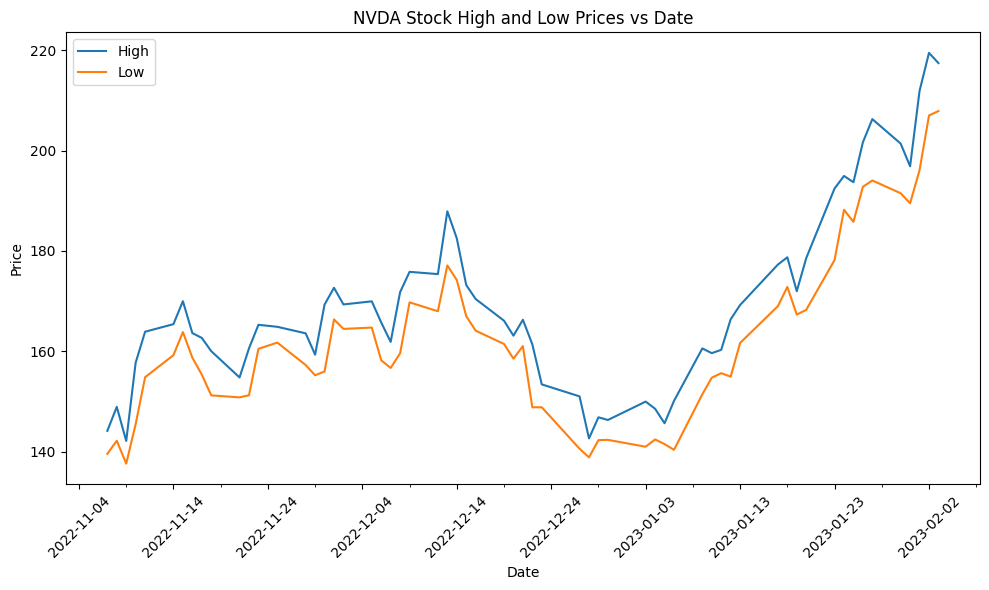

In [127]:
#fg = plt.subplots(figsize=(10,6))
# TODO: Plot the high and low prices, set the ticker intervals, x & y labels, and the plot title
# Convert the 'Date' column to datetime
stock_df['Date'] = pd.to_datetime(stock_df['Date'])

# Create the plot
fg = plt.subplots(figsize=(10,6))
sns.lineplot(data=stock_df, x='Date', y='High', label='High')
sns.lineplot(data=stock_df, x='Date', y='Low', label='Low')

# Set ticker intervals for x-axis
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(10))
plt.gca().xaxis.set_minor_locator(ticker.MaxNLocator(20))

# Rotate date labels for better readability
plt.xticks(rotation=45)

# Set labels and title
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('NVDA Stock High and Low Prices vs Date')

# Display the legend
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()

### Task 8:
Load openai_visits.csv to a DataFrame named as "visits_df".

This chart records worldwide visits to OpenAI.com from Nov 2022 to Feb 2023, and this period witnessed the sharp rise of ChatGPT and other generative applications.

In [128]:
# TODO: read csv to visits_df using Pandas
# Load the CSV file into a DataFrame named visits_df
visits_df = pd.read_csv('/content/drive/Othercomputers/Mac/Desktop/DS训练营/hw4/openai_visits.csv')
visits_df = visits_df.drop(columns=['Unnamed: 0'])
print(visits_df.columns)
# Display the first few rows of visits_df to check the data
print(visits_df.head())


Index(['Date', 'Visits'], dtype='object')
         Date  Visits
0  2022-11-07  650900
1  2022-11-08  659400
2  2022-11-09  693300
3  2022-11-10  642000
4  2022-11-11  579700


In [129]:
print(stock_df.columns)

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')


In [130]:
# TODO: merge stock_df with visits_df to stock_df, using the 'Date' column as anchor
# Convert the 'Date' column to datetime in both dataframes to ensure proper merging
visits_df['Date'] = pd.to_datetime(visits_df['Date'])

# Merge stock_df with visits_df on the 'Date' column
merged_df = pd.merge(stock_df, visits_df, on='Date', how='inner')

# Display the first few rows of the merged dataframe to check the merge
print(merged_df.head())

# Update stock_df with the merged dataframe
stock_df = merged_df


        Date        Open        High         Low       Close   Adj Close  \
0 2022-11-07  142.279999  144.119995  139.539993  143.009995  142.910004   
1 2022-11-08  148.009995  148.910004  142.160004  146.020004  145.917923   
2 2022-11-09  141.619995  142.110001  137.589996  137.759995  137.663681   
3 2022-11-10  148.000000  157.729996  145.470001  157.500000  157.389893   
4 2022-11-11  158.070007  163.889999  154.820007  163.270004  163.155869   

     Volume  Visits  
0  41006100  650900  
1  59529200  659400  
2  45441400  693300  
3  70081900  642000  
4  65548700  579700  


### Task 9:
in a single figure, plot the closing price of NVDA in lineplot, and number of OpenAI visits in barplot.

In [135]:
stock_df['Date'] = pd.to_datetime(stock_df['Date'])

print(stock_df.columns)

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume',
       'Visits'],
      dtype='object')


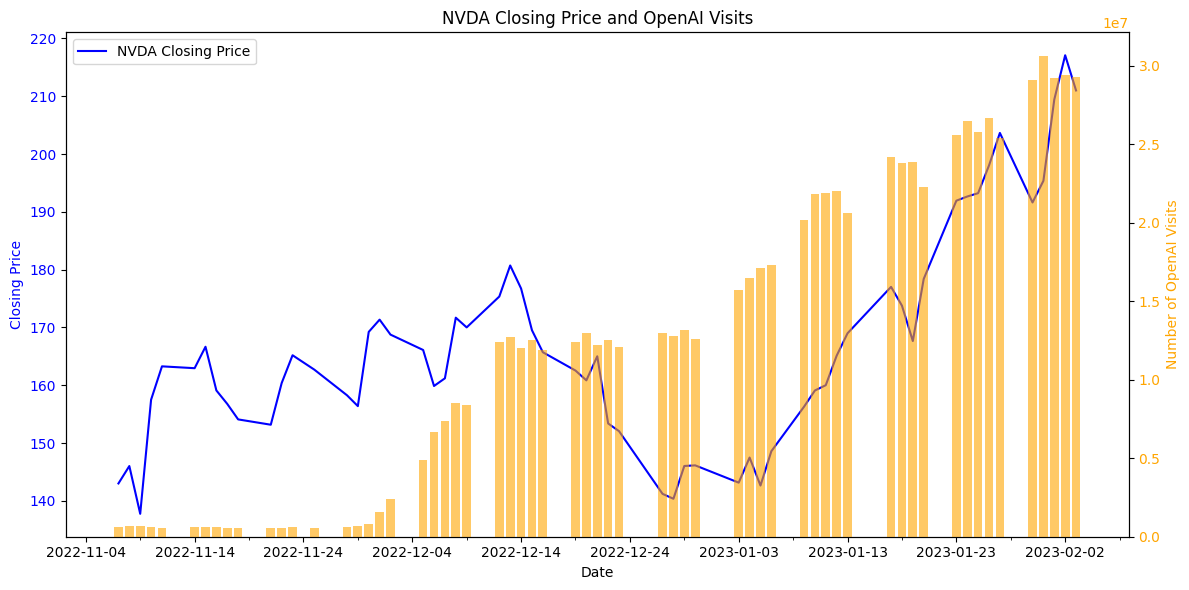

In [137]:
fg, ax1 = plt.subplots(figsize=(12,6))
# TODO: plot the stock closing price with lineplot in ax1
sns.lineplot(data=stock_df, x='Date', y='Close', ax=ax1, color='blue', label='NVDA Closing Price')
ax1.set_xlabel('Date')
ax1.set_ylabel('Closing Price', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
# TODO: plot the openai visits with barplot in ax2, set the x-axis ticker interval
#Plot the OpenAI visits with a bar plot on ax2
ax2.bar(stock_df['Date'], stock_df['Visits'], color='orange', alpha=0.6, label='OpenAI Visits')
ax2.set_ylabel('Number of OpenAI Visits', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

# Set x-axis ticker interval for better readability
ax1.xaxis.set_major_locator(ticker.MaxNLocator(10))
ax1.xaxis.set_minor_locator(ticker.MaxNLocator(20))
plt.xticks(rotation=45)

# Set the title of the plot
plt.title('NVDA Closing Price and OpenAI Visits')

# Display the legend for the line plot
ax1.legend(loc='upper left')

# Display the plot
plt.tight_layout()
plt.show()